# **Controller Analysis**

IBVS P Controller with 4 DOF

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
first_log_df = pd.read_csv("controller_log_20260318_031706.csv")
first_log_df.head()

,time,det_valid,det_conf,det_t,det_u,det_v,det_w,det_h,det_theta,u_filtered,...,e_u,e_v,e_area,e_theta,vx,vy,vz,wx,wy,wz
0,1.773775e+09,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
1,1.773775e+09,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
2,1.773775e+09,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
3,1.773775e+09,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
4,1.773775e+09,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0


### Box Area over Time

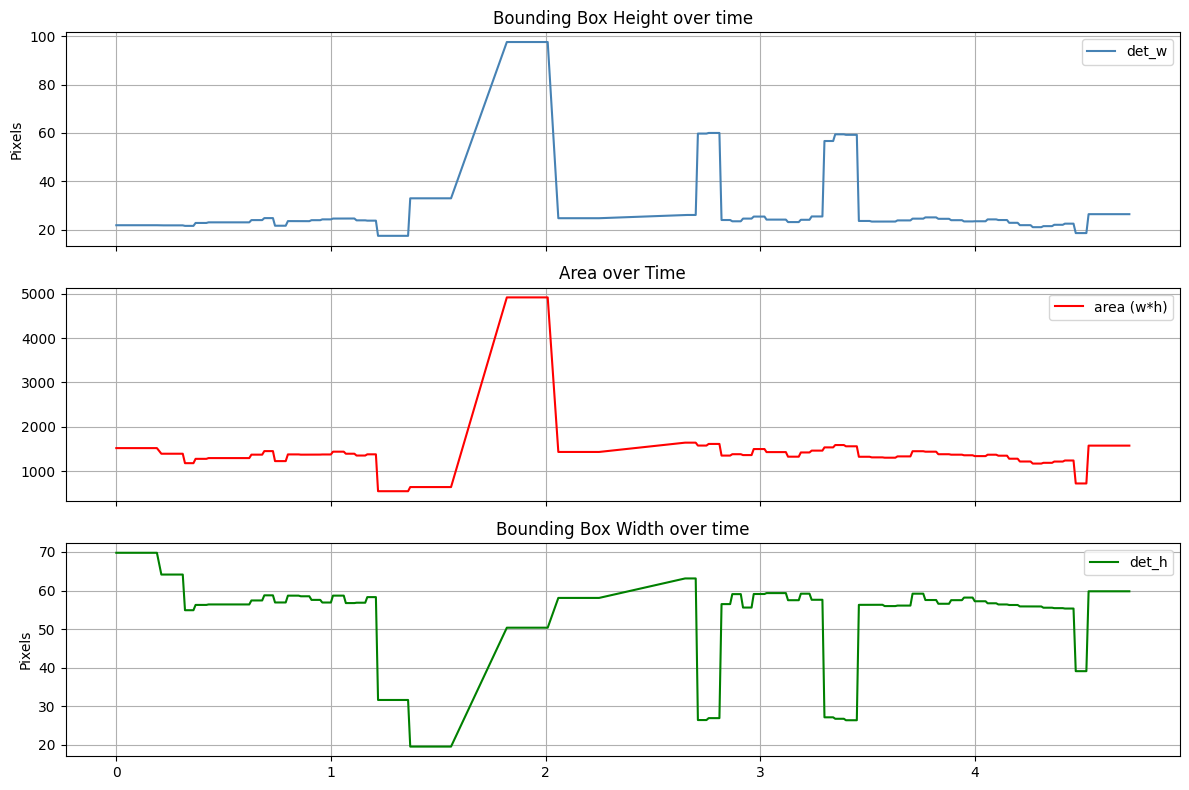

1495.5558373617891


In [10]:
valid = first_log_df[first_log_df['det_valid'] == True].copy()
valid['time_rel'] = valid['time'] - valid['time'].iloc[0]

fig, axes = plt.subplots(3, 1, figsize=(12,8), sharex=True)

# Width 
axes[0].plot(valid['time_rel'], valid['det_w'], label='det_w', color='steelblue')
# axes[0].plot(valid['time_rel'], valid['det_h'], label='det_h', color='red')
axes[0].set_ylabel('Pixels')
axes[0].set_title('Bounding Box Height over time')
axes[0].legend()
axes[0].grid(True)

# Area
valid['area'] = valid['det_w'] * valid['det_h']
axes[1].plot(valid['time_rel'], valid['area'], label='area (w*h)', color='red')
axes[1].set_title('Area over Time')
axes[1].legend()
axes[1].grid(True)

# Height
# axes[2].plot(valid['time_rel'], valid['det_w'], label='det_w', color='steelblue')
axes[2].plot(valid['time_rel'], valid['det_h'], label='det_h', color='green')
axes[2].set_ylabel('Pixels')
axes[2].set_title('Bounding Box Width over time')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

print(valid['area'].mean())

### Error vs Velocity (e_u -> vx, e_v -> vy, e_area -> vz, e_theta -> wz)

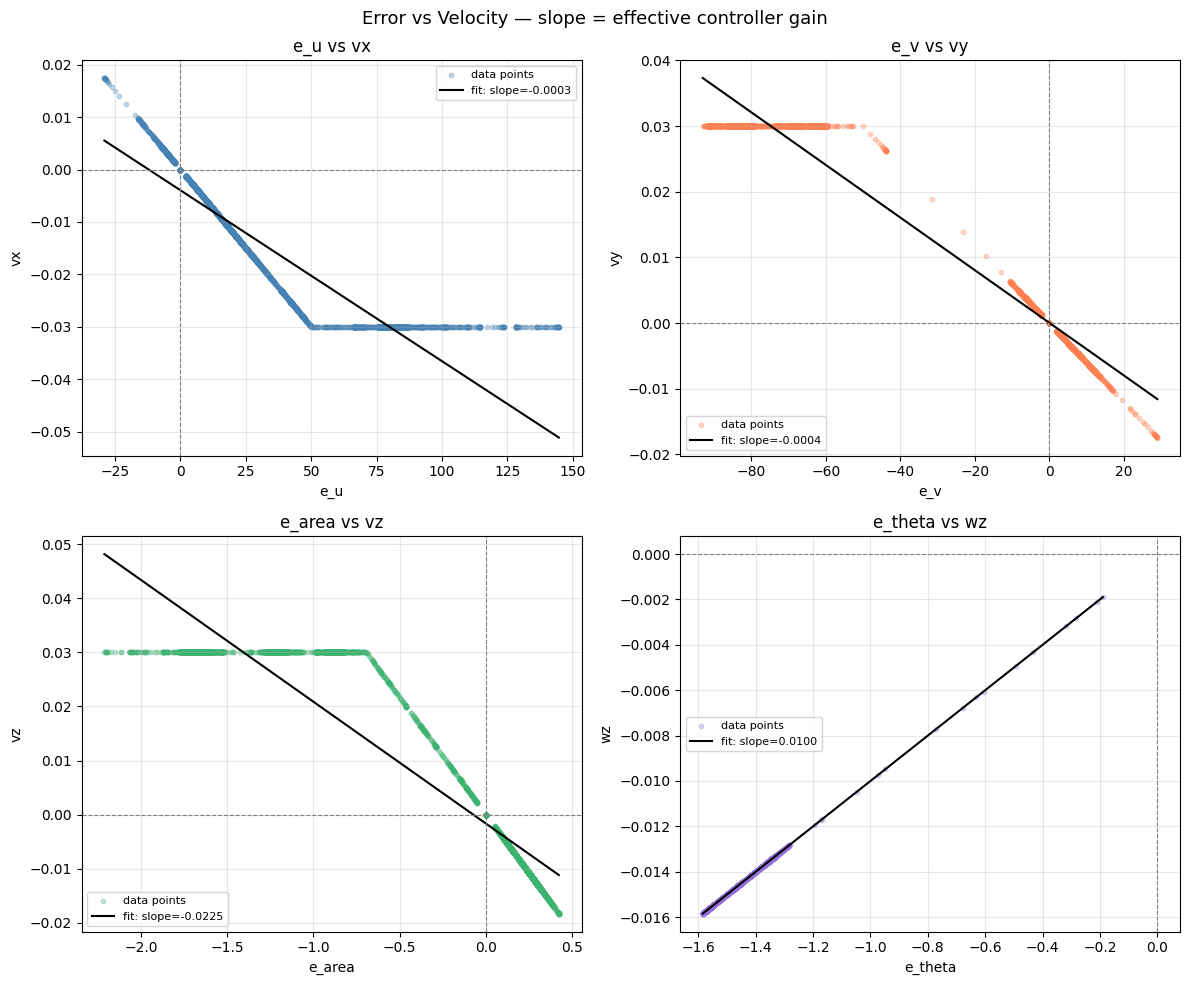

,time,det_valid,det_conf,det_t,det_u,det_v,det_w,det_h,det_theta,u_filtered,...,e_u,e_v,e_area,e_theta,vx,vy,vz,wx,wy,wz
0,1.773776e+09,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
1,1.773776e+09,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
2,1.773776e+09,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
3,1.773776e+09,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
4,1.773776e+09,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('controller_log_20260318_033204.csv')
valid = df[df['det_valid'] == True].copy()

pairs = [
    ('e_u',     'vx',  'e_u vs vx',     'steelblue'),
    ('e_v',     'vy',  'e_v vs vy',     'coral'),
    ('e_area',  'vz',  'e_area vs vz',  'mediumseagreen'),
    ('e_theta', 'wz',  'e_theta vs wz', 'mediumpurple'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (err_col, vel_col, title, color) in zip(axes, pairs):
    x = valid[err_col]
    y = valid[vel_col]

    ax.scatter(x, y, alpha=0.3, s=10, color=color, label='data points')

    # Fit a line to see how close it is to a pure P controller
    coeffs = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = np.polyval(coeffs, x_line)
    ax.plot(x_line, y_line, color='black', linewidth=1.5,
            label=f'fit: slope={coeffs[0]:.4f}')

    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')

    ax.set_xlabel(err_col)
    ax.set_ylabel(vel_col)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Error vs Velocity — slope = effective controller gain', fontsize=13)
plt.tight_layout()
plt.savefig('error_vs_velocity_scatter.png', dpi=150)
plt.show()

df.head()

In [7]:
print(valid['area'].mean())

KeyError: 'area'